# Fire & Smoke Detection
By _**George Malak Magdy**_

SRC : [Smoke-Fire-Detection-YOLO](https://www.kaggle.com/datasets/sayedgamal99/smoke-fire-detection-yolo)

# Libraries

In [3]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.0 MB/s eta 0:00:00a 0:00:01


In [4]:
import os
import glob
import yaml
from ultralytics import YOLO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Helper Functions

In [5]:
def balancer(labels_path,datasetTYPE):
    label_files = glob.glob(os.path.join(labels_path, "*.txt"))
    classes = []

    for file in label_files:
        with open(file, 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                classes.append("smoke" if class_id == 0 else "fire")

    df = pd.DataFrame(classes, columns=["Class"])
    plt.figure(figsize=(8, 5))
    sns.countplot(x="Class", data=df, palette="viridis")
    plt.title(f"Class Distribution for {datasetTYPE}")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

In [6]:
def plot_box_sizes(labels_path,datasetTYPE):
    box_sizes = []
    for file in glob.glob(os.path.join(labels_path, "*.txt")):
        with open(file, 'r') as f:
            for line in f:
                _, _, _, w, h = map(float, line.split())
                box_sizes.append(w * h)

    plt.hist(box_sizes, bins=50, color='orange')
    plt.title(f"Distribuion of Bounding Boxes {datasetTYPE}")
    plt.xlabel("Area of Bounding Box")
    plt.ylabel("Count of Bounding Boxes")
    plt.show()

In [32]:
def show_box(image_path, label_data, is_model=False):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error in load IMG --> {image_path}")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    lines = []

    if not is_model:
        with open(label_data, 'r') as f:
            lines = [line.split() for line in f.readlines()]
    else:
        boxes = label_data
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            lines.append([cls, x1, y1, x2, y2, conf, True])

    for line in lines:
        if len(line) == 7:
            cls, x1, y1, x2, y2, conf, _ = line
        else:
            cls = int(line[0])
            x_c, y_c, box_w, box_h = map(float, line[1:])
            x1 = int((x_c - box_w/2) * w)
            y1 = int((y_c - box_h/2) * h)
            x2 = int((x_c + box_w/2) * w)
            y2 = int((y_c + box_h/2) * h)
            conf = None

        color = (255, 0, 0) if cls == 1 else (0, 0, 255) # red for fire, blue for smoke
        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)

        label_name = "Smoke" if cls == 0 else "Fire"
        text = f"{label_name} {conf:.2f}" if conf is not None else label_name
        
        y1 = max(int(y1) - 10, 15)
        cv2.putText(img, text, (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [8]:
def preprocess_dataset(input_folder, output_folder, target_size=(640, 640)):
    """
    take img with their labels and preproceesing them and save them in the output folder
    """

    in_images_dir = os.path.join(input_folder, 'images')
    in_labels_dir = os.path.join(input_folder, 'labels')

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    out_images_dir = os.path.join(output_folder, 'images')
    out_labels_dir = os.path.join(output_folder, 'labels')


    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_labels_dir, exist_ok=True)


    image_files = [f for f in os.listdir(in_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f" Process {len(image_files)}")

    for img_name in image_files:
        img_path = os.path.join(in_images_dir, img_name)

        # read img
        image = cv2.imread(img_path)
        if image is None:
            continue

        # resize for yolo 640*640
        resized_img = cv2.resize(image, target_size)

        # reduce the brithness
        hsv = cv2.cvtColor(resized_img, cv2.COLOR_BGR2HSV)
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * 0.6, 0, 255)
        processed_img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

        # save with same name
        out_img_path = os.path.join(out_images_dir, img_name)
        cv2.imwrite(out_img_path, processed_img)

        # save with label
        label_name = os.path.splitext(img_name)[0] + '.txt'
        in_label_path = os.path.join(in_labels_dir, label_name)
        out_label_path = os.path.join(out_labels_dir, label_name)
        # print(f"img {img_name} Finisheed")

        if os.path.exists(in_label_path):
            with open(in_label_path, 'r') as f_in:
                label_data = f_in.read()

            with open(out_label_path, 'w') as f_out:
                f_out.write(label_data)

    print("✓ Finished !")

# Load dataset

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo


In [10]:
con = os.listdir(path)
path = os.path.join(path, con[1])
print(path)

/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data


In [11]:
train_data_path = os.path.join(path, 'train')
val_data_path = os.path.join(path, 'val')
test_data_path = os.path.join(path, 'test')

In [12]:
contian_folder_path = os.listdir(train_data_path)
print(contian_folder_path)
contian_folder_path = os.listdir(val_data_path)
print(contian_folder_path)
contian_folder_path = os.listdir(test_data_path)
print(contian_folder_path)

['labels', 'images']
['labels', 'images']
['labels', 'images']


In [13]:
print("In Train File:")
print(f"Number of Images: {len(os.listdir(os.path.join(train_data_path, 'images')))}")
print(f"Number of Labels: {len(os.listdir(os.path.join(train_data_path, 'labels')))}")
print("\nIn Validation File:")
print(f"Number of Images: {len(os.listdir(os.path.join(val_data_path, 'images')))}")
print(f"Number of Labels: {len(os.listdir(os.path.join(val_data_path, 'labels')))}")
print("\nIn Test File:")
print(f"Number of Images: {len(os.listdir(os.path.join(test_data_path, 'images')))}")
print(f"Number of Labels: {len(os.listdir(os.path.join(test_data_path, 'labels')))}")

In Train File:
Number of Images: 14122
Number of Labels: 14122

In Validation File:
Number of Images: 3099
Number of Labels: 3099

In Test File:
Number of Images: 4306
Number of Labels: 4306


# EDA

/tmp/ipykernel_58/1676452708.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette="viridis")


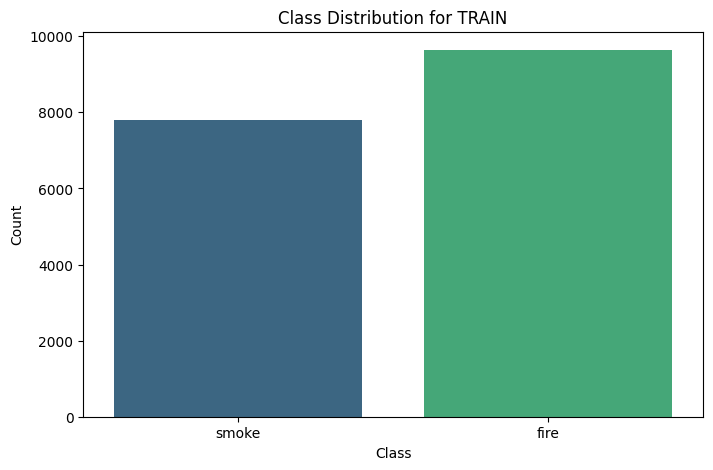

/tmp/ipykernel_58/1676452708.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette="viridis")


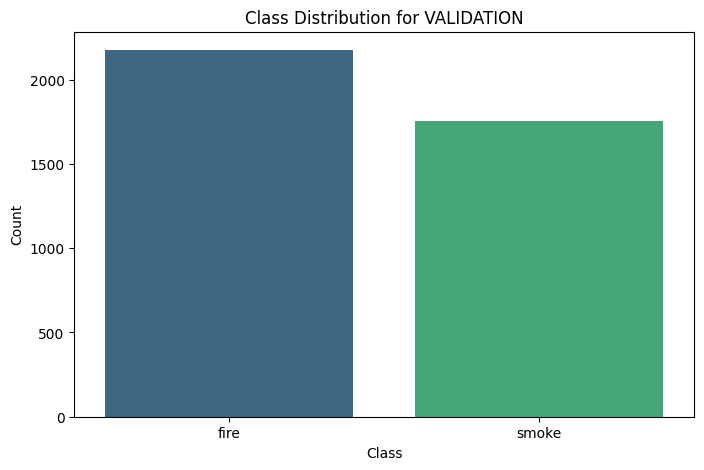

/tmp/ipykernel_58/1676452708.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette="viridis")


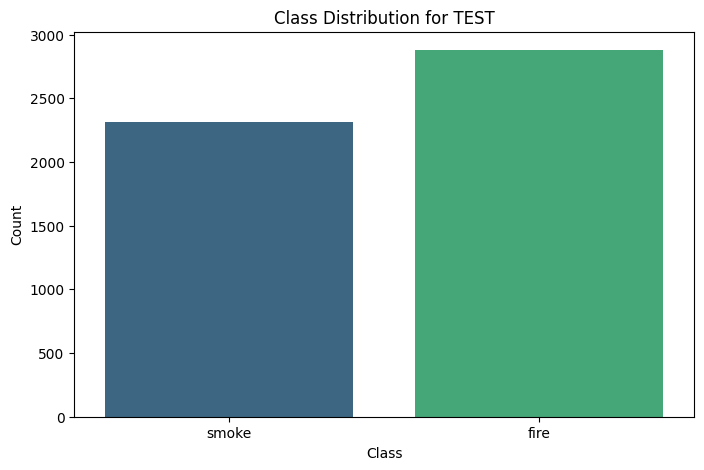

In [14]:
lable_train = train_data_path+"/labels"
lable_val = val_data_path+"/labels"
lable_test = test_data_path+"/labels"

balancer(lable_train,"TRAIN")
balancer(lable_val,"VALIDATION")
balancer(lable_test,"TEST")

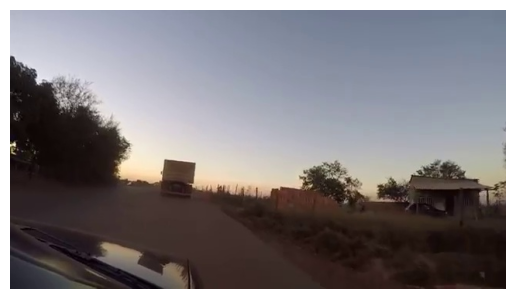

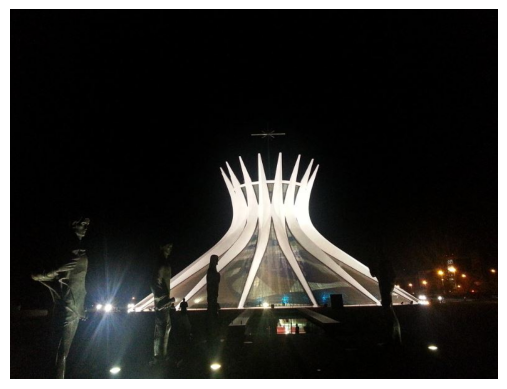

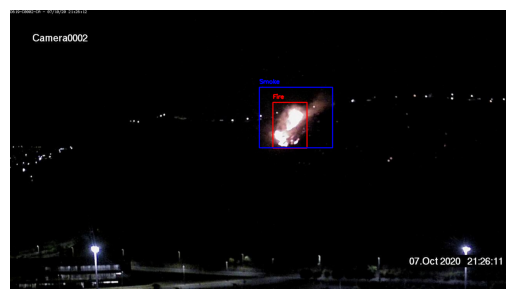

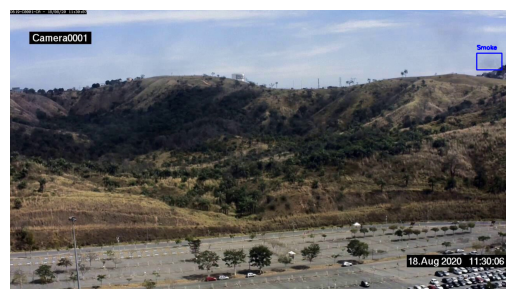

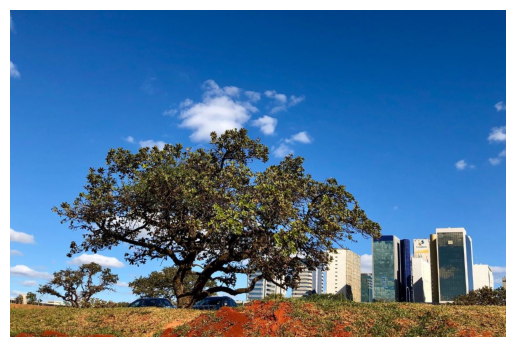

In [15]:
import random
images_path = os.path.join(train_data_path, "images")
labels_path = lable_train
num_samples = 5

all_lab_fil = [f for f in os.listdir(labels_path) if f.endswith('.txt')]

random_lab_fil = random.sample(all_lab_fil, num_samples)

for label_file in random_lab_fil:
    file_name = os.path.splitext(label_file)[0]

    image_file = None
    for ext in ['.jpg', '.png', '.jpeg']:
        potential_path = os.path.join(images_path, file_name + ext)
        if os.path.exists(potential_path):
            image_file = potential_path
            break

    if image_file:
        label_file_path = os.path.join(labels_path, label_file)
        show_box(image_file, label_file_path,False)
    else:
        print(f"NOT FOUND BRO {label_file}")


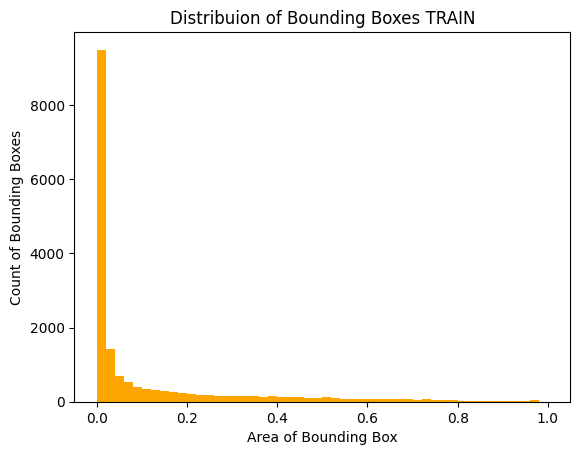

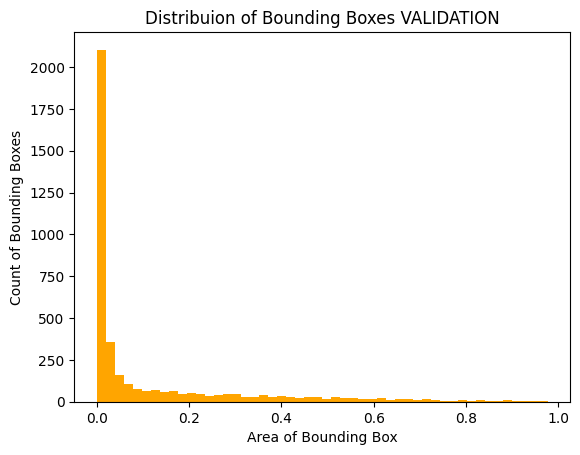

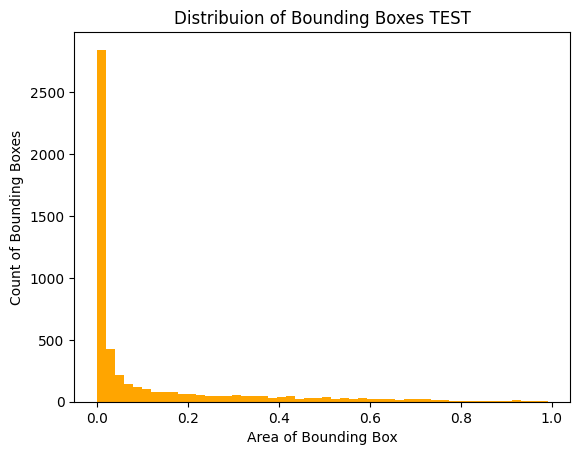

In [16]:
plot_box_sizes(lable_train, "TRAIN")
plot_box_sizes(lable_val,"VALIDATION")
plot_box_sizes(lable_test,"TEST")

# Preprocessing

In [17]:
process_data_path = "ready_dataset"

splits = {
    "train": train_data_path,
    "val": val_data_path,
    "test": test_data_path
}

for split_name, input_folder_path in splits.items():
    output_folder = os.path.join(process_data_path, split_name)
    preprocess_dataset(input_folder_path, output_folder)


 Process 14122
✓ Finished !
 Process 3099
✓ Finished !
 Process 4306
✓ Finished !


In [ ]:
# show Example
import random
process_data_path = "ready_dataset"
train_data_path = os.path.join(process_data_path, 'train')
images_path = os.path.join(train_data_path, "images")
labels_path = lable_train
num_samples = 5

all_lab_fil = [f for f in os.listdir(labels_path) if f.endswith('.txt')]

random_lab_fil = random.sample(all_lab_fil, num_samples)

for label_file in random_lab_fil:
    file_name = os.path.splitext(label_file)[0]

    image_file = None
    for ext in ['.jpg', '.png', '.jpeg']:
        potential_path = os.path.join(images_path, file_name + ext)
        if os.path.exists(potential_path):
            image_file = potential_path
            break

    if image_file:
        label_file_path = os.path.join(labels_path, label_file)
        show_box(image_file, label_file_path,False)
    else:
        print(f"NOT FOUND BRO {label_file}")

# Train Model

In [ ]:
yaml_content = {
    'train': os.path.join(process_data_path, 'train', 'images'),
    'val': os.path.join(process_data_path, 'val', 'images'),
    'test': os.path.join(process_data_path, 'test', 'images'),
    'nc': 2,
    'names': ['smoke', 'fire']
}


yaml_file_path = '/kaggle/working/data.yaml'


with open(yaml_file_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print(" Created data.yaml !")

In [20]:
myYolo = YOLO('yolov8s.pt')
results = myYolo.train(
    data=yaml_file_path,
    epochs=50,
    imgsz=640,
    batch=16,
    project='/kaggle/working/runs',
    name='smoke_fire_detection',
    save=True,                    
    save_period=5
)

       1/50      3.73G      1.636      2.297      1.628         14        640: 100% ━━━━━━━━━━━━ 883/883 3.3it/s 4:260.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 97/97 4.0it/s 24.4s0.2ss
                   all       3099       3932      0.495      0.441      0.412      0.187

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      4.51G      1.645      1.866        1.6         26        640: 100% ━━━━━━━━━━━━ 883/883 3.5it/s 4:110.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 97/97 4.0it/s 24.2s0.3ss
                   all       3099       3932      0.438      0.411      0.371      0.158

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      4.51G      1.757      2.064      1.712         21        640: 100% ━━━━━━━━━━━━ 883/883 3.7it/s 4:020.2ss
                 Class     Im

#  Predict

In [ ]:
results = myYolo.predict(
    source='/kaggle/working/ready_dataset/test/images',
    conf=0.35,                                          
    save=True,                                         
    project='/kaggle/working/runs',
    name='test_predictions'                           
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/4306 /kaggle/working/ready_dataset/test/images/AoF06723.jpg: 640x640 (no detections), 16.3ms
image 2/4306 /kaggle/working/ready_dataset/test/images/AoF06724.jpg: 640x640 (no detections), 16.1ms
image 3/4306 /kaggle/working/ready_dataset/test/images/AoF06725.jpg: 640x640 (no detections), 16.2ms
image 4/4306 /kaggle/working/ready_dataset/test/images/AoF06726.jpg: 640x640 (no detections), 16.2ms
image 5/4306 /kaggle/working/ready_dataset/test/images

Showing predictions for: /kaggle/working/ready_dataset/test/images/AoF07789.jpg


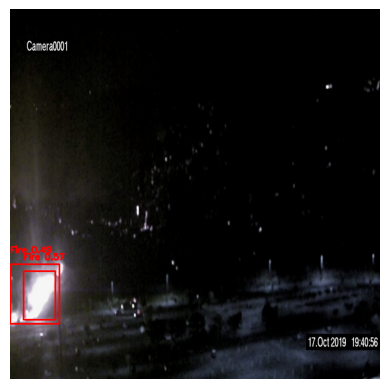

Showing predictions for: /kaggle/working/ready_dataset/test/images/AoF07948.jpg


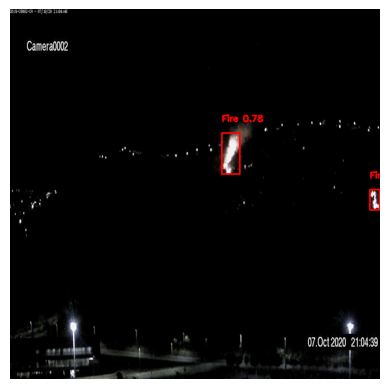

Showing predictions for: /kaggle/working/ready_dataset/test/images/AoF07039.jpg


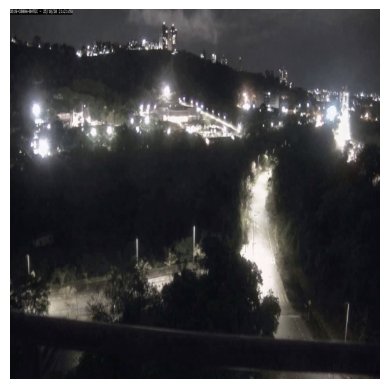

Showing predictions for: /kaggle/working/ready_dataset/test/images/AoF07380.jpg


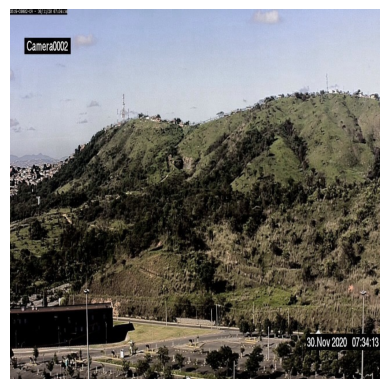

Showing predictions for: /kaggle/working/ready_dataset/test/images/WEB10706.jpg


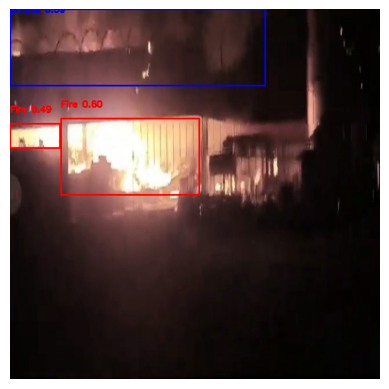

Showing predictions for: /kaggle/working/ready_dataset/test/images/WEB11798.jpg


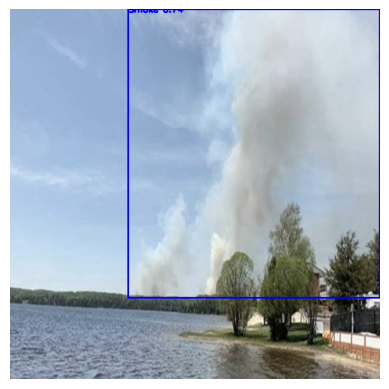

In [50]:
import random

num_samples = min(6, len(results))  

rand_img = random.sample(results, num_samples)

for r in rand_img:
    img_path = r.path
    boxes = r.boxes
    
    print(f"Showing predictions for: {img_path}")
    show_box(img_path, label_data=boxes, is_model=True)

# Accuracy

In [36]:
run_dir = '/kaggle/working/runs/smoke_fire_detection'
csv_path = os.path.join(run_dir, 'results.csv')
cm_path = os.path.join(run_dir, 'confusion_matrix.png')

In [39]:
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    
    # Calc F1 score for Epoo
    p = df['metrics/precision(B)']
    r = df['metrics/recall(B)']
    df['f1_score'] = 2 * (p * r) / (p + r + 1e-16)
    
    print("success :)")
else:
    print("Not Found Failed :(")


success :)


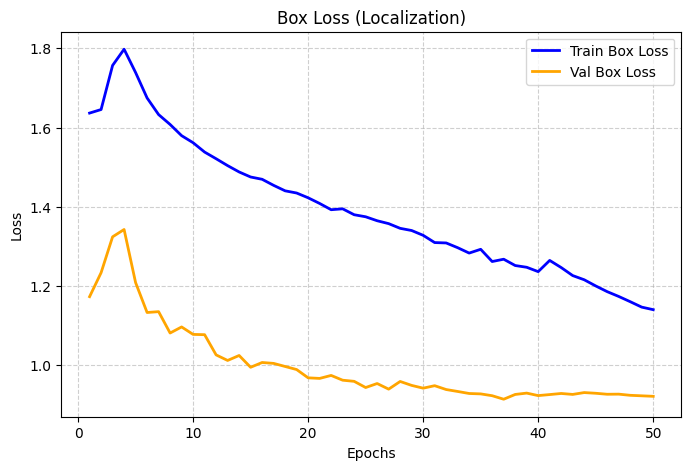

In [40]:
# Train and Val Loss
plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue', linewidth=2)
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='orange', linewidth=2)
plt.title('Box Loss (Localization)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

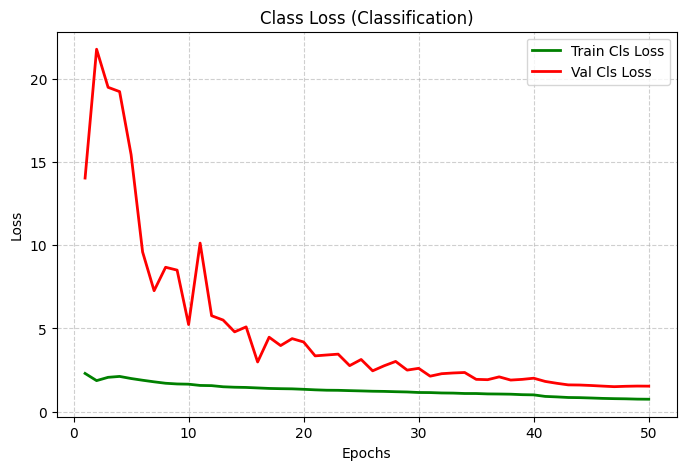

In [41]:
# Class Loss
plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss', color='green', linewidth=2)
plt.plot(df['epoch'], df['val/cls_loss'], label='Val Cls Loss', color='red', linewidth=2)
plt.title('Class Loss (Classification)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

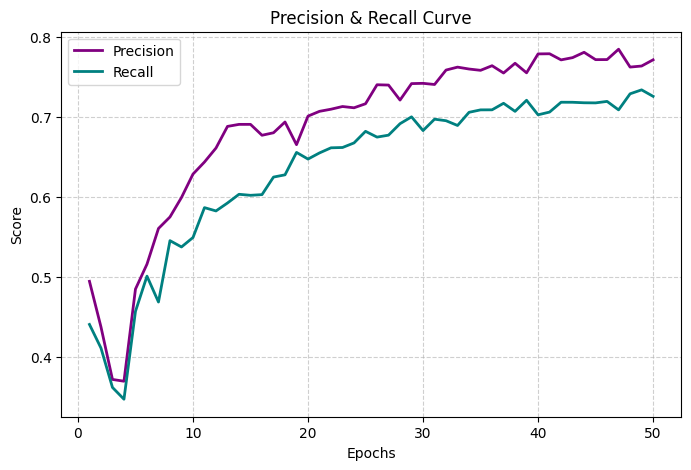

In [42]:
# Precision & Recall
plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='purple', linewidth=2)
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='teal', linewidth=2)
plt.title('Precision & Recall Curve')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

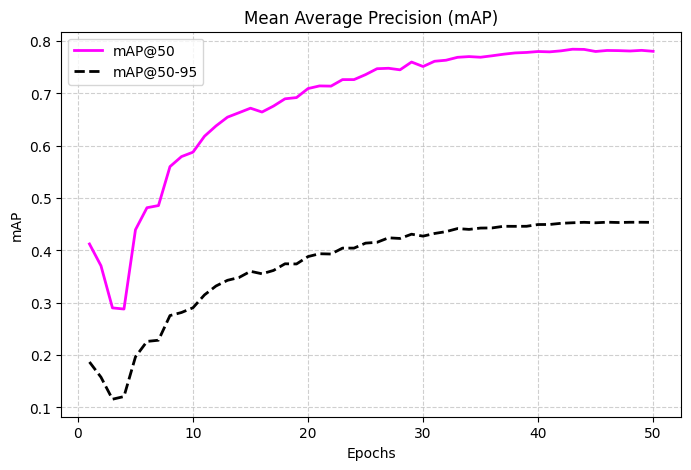

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='magenta', linewidth=2)
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='black', linestyle='--', linewidth=2)
plt.title('Mean Average Precision (mAP)')
plt.xlabel('Epochs')
plt.ylabel('mAP')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

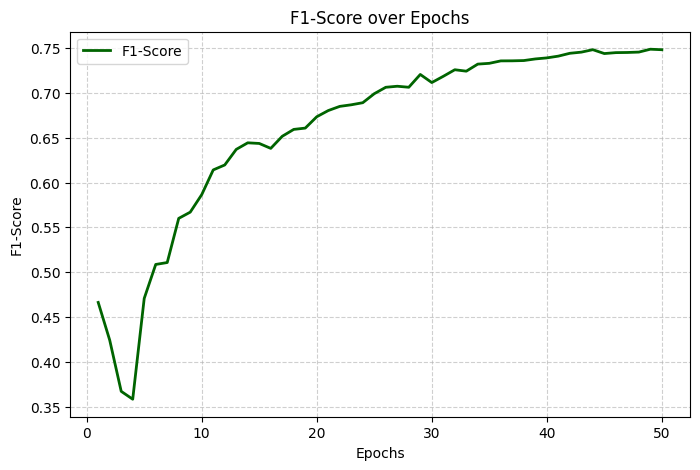

In [44]:
# F1 SCore
plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['f1_score'], label='F1-Score', color='darkgreen', linewidth=2)
plt.title('F1-Score over Epochs')
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

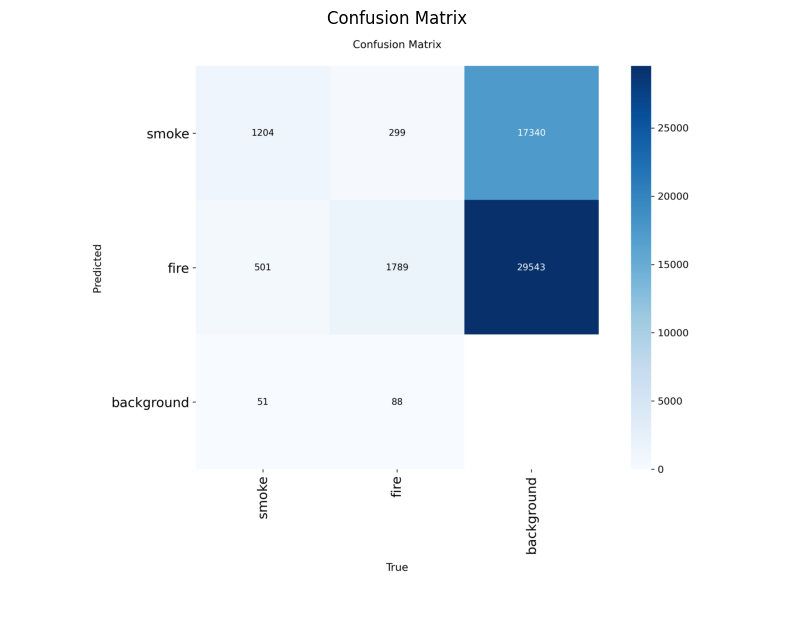

In [46]:
cm_img = cv2.imread(cm_path)
cm_img = cv2.cvtColor(cm_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(cm_img)
plt.title('Confusion Matrix')
plt.axis('off')
plt.show()

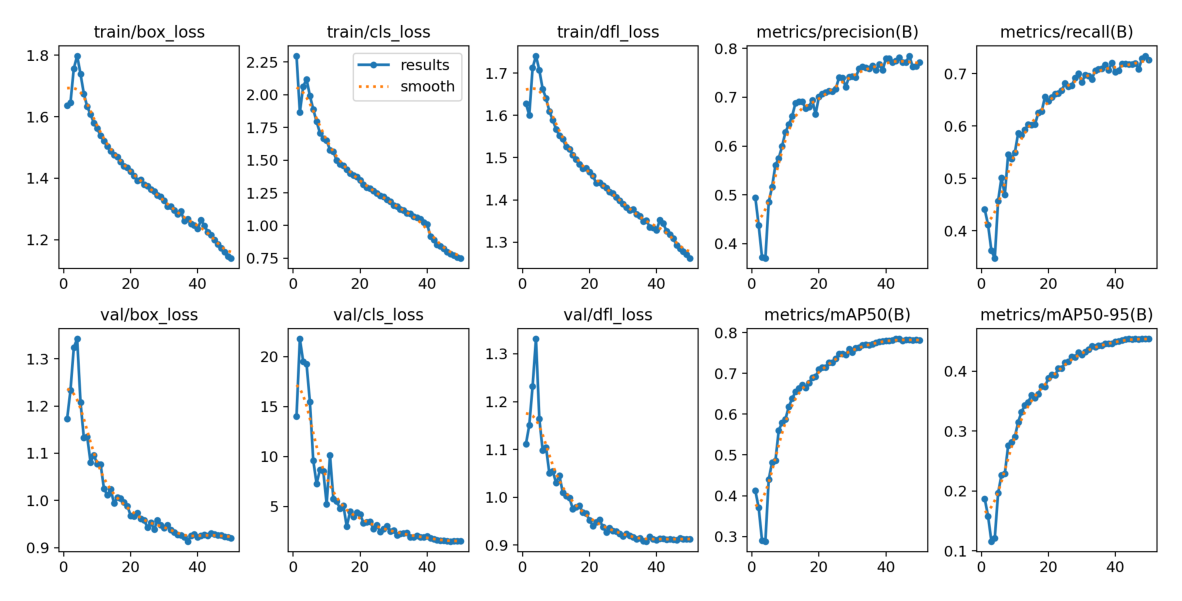

In [23]:
results_path = '/kaggle/working/runs/smoke_fire_detection/results.png'

img = cv2.imread(results_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.axis('off')  
plt.show()

# Save Model For Deploy

In [51]:
model = YOLO('/kaggle/working/runs/smoke_fire_detection/weights/best.pt')

#as ONNX
model.export(format='onnx')

Ultralytics 8.4.110 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/kaggle/working/runs/smoke_fire_detection/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 346ms
Prepared 2 packages in 359ms
Installed 2 packages in 13ms
 + onnxruntime==1.28.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success 

'/kaggle/working/runs/smoke_fire_detection/weights/best.onnx'